#Preparación de los Datos

##Extracción del Archivo Tratado


In [6]:
import pandas as pd
df = pd.read_csv('telecom_limpio.csv')
print(df.info())

df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customerID              7043 non-null   object 
 1   Churn                   7043 non-null   int64  
 2   Género                  7043 non-null   object 
 3   Adulto_Mayor            7043 non-null   int64  
 4   Socio                   7043 non-null   object 
 5   Dependientes            7043 non-null   object 
 6   Meses_Antiguedad        7043 non-null   int64  
 7   Servicio_Telefonico     7043 non-null   object 
 8   phone_MultipleLines     7043 non-null   object 
 9   Tipo_Internet           7043 non-null   object 
 10  net_OnlineSecurity      7043 non-null   object 
 11  net_OnlineBackup        7043 non-null   object 
 12  net_DeviceProtection    7043 non-null   object 
 13  net_TechSupport         7043 non-null   object 
 14  net_StreamingTV         7043 non-null   

,customerID,Churn,Género,Adulto_Mayor,Socio,Dependientes,Meses_Antiguedad,Servicio_Telefonico,phone_MultipleLines,Tipo_Internet,...,net_DeviceProtection,net_TechSupport,net_StreamingTV,net_StreamingMovies,Tipo_Contrato,acc_PaperlessBilling,acc_PaymentMethod,Cargos_Mensuales_Total,acc_Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3,2.19
1,0003-MKNFE,0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4,2.00
2,0004-TLHLJ,1,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.46
3,0011-IGKFF,1,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,1,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,0,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.9,1.84
7039,9992-RRAMN,1,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7,2.84
7040,9992-UJOEL,0,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.68
7041,9993-LHIEB,0,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.26


##Eliminación de Columnas Irrelevantes

In [7]:
columnas_a_eliminar = [
    'customerID',
    'acc_Charges.Total',
    'Cuentas_Diarias'
]

df_ml = df.drop(columns=[col for col in columnas_a_eliminar if col in df.columns])

print(f"Columnas después de la limpieza: {len(df_ml.columns)}")
print(df_ml.columns.tolist())

Columnas después de la limpieza: 19
['Churn', 'Género', 'Adulto_Mayor', 'Socio', 'Dependientes', 'Meses_Antiguedad', 'Servicio_Telefonico', 'phone_MultipleLines', 'Tipo_Internet', 'net_OnlineSecurity', 'net_OnlineBackup', 'net_DeviceProtection', 'net_TechSupport', 'net_StreamingTV', 'net_StreamingMovies', 'Tipo_Contrato', 'acc_PaperlessBilling', 'acc_PaymentMethod', 'Cargos_Mensuales_Total']


##Encoding

In [8]:

columnas_categoricas = df_ml.select_dtypes(include=['object']).columns.tolist()

df_model = pd.get_dummies(df_ml, columns=columnas_categoricas, drop_first=True)

df_model

,Churn,Adulto_Mayor,Meses_Antiguedad,Cargos_Mensuales_Total,Género_Male,Socio_Yes,Dependientes_Yes,Servicio_Telefonico_Yes,phone_MultipleLines_No phone service,phone_MultipleLines_Yes,...,net_StreamingTV_No internet service,net_StreamingTV_Yes,net_StreamingMovies_No internet service,net_StreamingMovies_Yes,Tipo_Contrato_One year,Tipo_Contrato_Two year,acc_PaperlessBilling_Yes,acc_PaymentMethod_Credit card (automatic),acc_PaymentMethod_Electronic check,acc_PaymentMethod_Mailed check
0,0,0,9,65.60,False,True,True,True,False,False,...,False,True,False,False,True,False,True,False,False,True
1,0,0,9,59.90,True,False,False,True,False,True,...,False,False,False,True,False,False,False,False,False,True
2,1,0,4,73.90,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
3,1,1,13,98.00,True,True,False,True,False,False,...,False,True,False,True,False,False,True,False,True,False
4,1,1,3,83.90,False,True,False,True,False,False,...,False,True,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,13,55.15,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
7039,1,0,22,85.10,True,True,False,True,False,True,...,False,False,False,True,False,False,True,False,True,False
7040,0,0,2,50.30,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
7041,0,0,67,67.85,True,True,True,True,False,False,...,False,False,False,True,False,True,False,False,False,True


##Verificación de la Proporción de Cancelación (Churn)

--- Conteo de Clientes ---
Churn
0    5174
1    1869
Name: count, dtype: int64

--- Proporción Porcentual ---
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


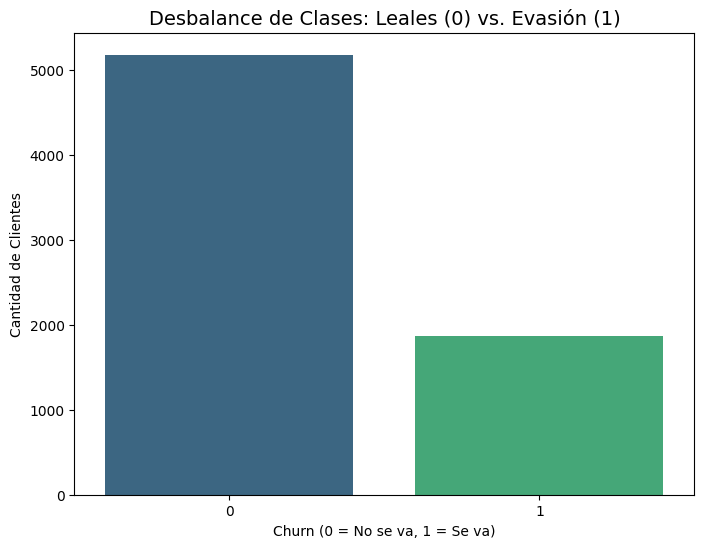

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

conteo_churn = df['Churn'].value_counts()


proporcion_churn = (df['Churn'].value_counts(normalize=True) * 100).round(2)

print("--- Conteo de Clientes ---")
print(conteo_churn)
print("\n--- Proporción Porcentual ---")
print(proporcion_churn)

plt.figure(figsize=(8, 6))
sns.countplot(x='Churn', data=df, hue='Churn', palette='viridis', legend=False)
plt.title('Desbalance de Clases: Leales (0) vs. Evasión (1)', fontsize=14)
plt.xlabel('Churn (0 = No se va, 1 = Se va)')
plt.ylabel('Cantidad de Clientes')
plt.show()

##Balanceo de Clases (opcional)

In [10]:
!pip install imbalanced-learn

In [11]:
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

from imblearn.over_sampling import SMOTE

smt = SMOTE(random_state=123)

X_res, y_res = smt.fit_resample(X, y)

print("--- Balance después de SMOTE ---")
print(y_res.value_counts())

--- Balance después de SMOTE ---
Churn
0    5174
1    5174
Name: count, dtype: int64


##Normalización o Estandarización (si es necesario)

In [12]:
from sklearn.preprocessing import StandardScaler

cols_a_escalar = ['Meses_Antiguedad', 'Cargos_Mensuales_Total']

scaler = StandardScaler()

df_model[cols_a_escalar] = scaler.fit_transform(df_model[cols_a_escalar])

print("Datos escalados (Primeras 5 filas):")
print(df_model[cols_a_escalar].head())

Datos escalados (Primeras 5 filas):
   Meses_Antiguedad  Cargos_Mensuales_Total
0         -0.951682                0.027862
1         -0.951682               -0.161583
2         -1.155283                0.303720
3         -0.788800                1.104706
4         -1.196004                0.636080


#Correlación y Selección de Variables

#Análisis de Correlación

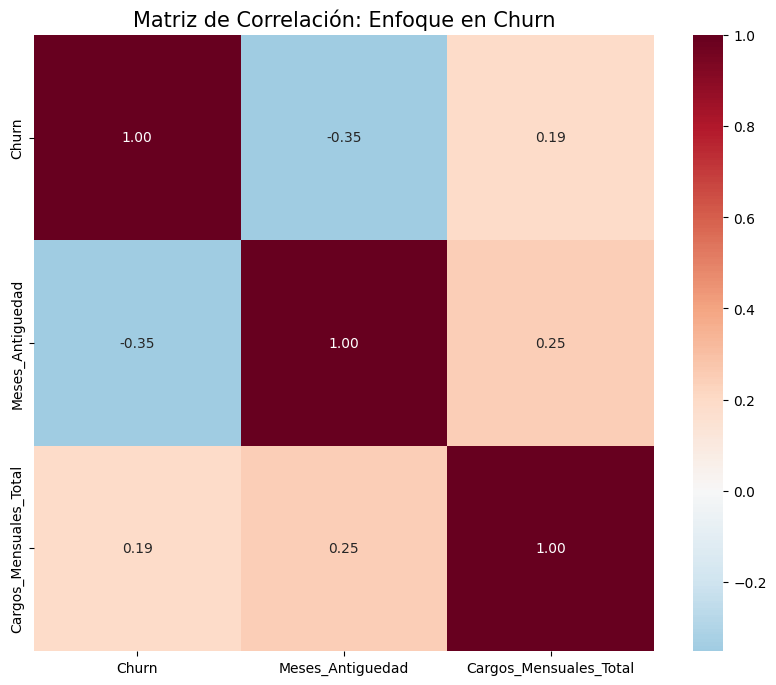

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

columnas_analisis = ['Churn', 'Meses_Antiguedad', 'Cargos_Mensuales_Total']

plt.figure(figsize=(10, 8))

sns.heatmap(df_model[columnas_analisis].corr(),
            annot=True,
            cmap='RdBu_r',
            fmt=".2f",
            center=0)

plt.title('Matriz de Correlación: Enfoque en Churn', fontsize=15)
plt.show()

#Análisis Dirigido

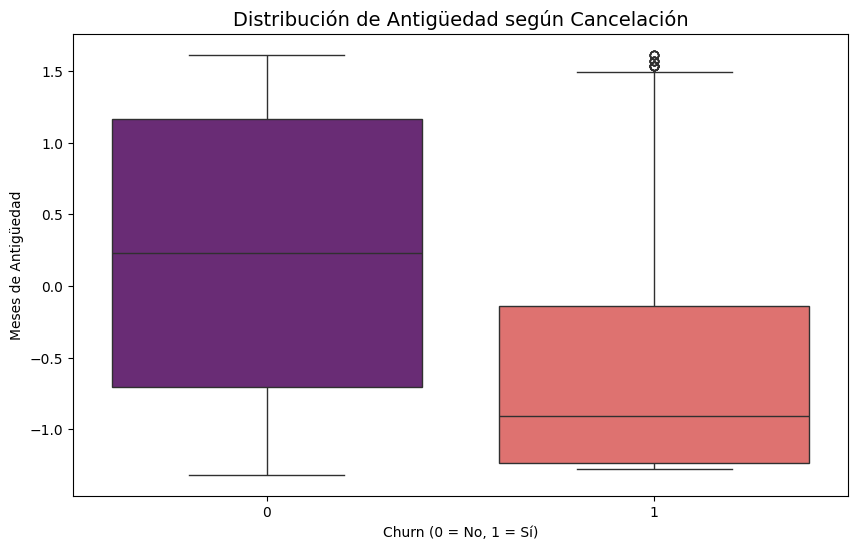

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='Meses_Antiguedad', data=df_model, hue='Churn', palette='magma', legend=False)
plt.title('Distribución de Antigüedad según Cancelación', fontsize=14)
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Meses de Antigüedad')
plt.show()

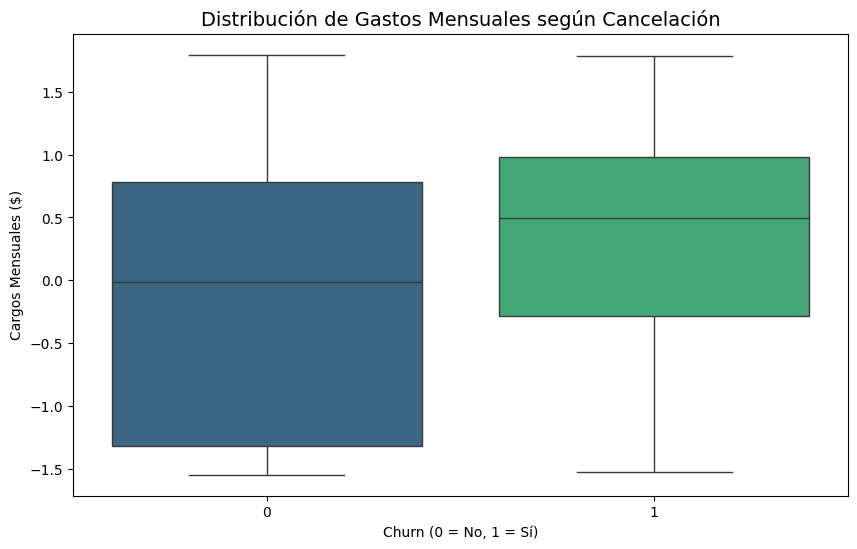

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='Cargos_Mensuales_Total', data=df_model, hue='Churn', palette='viridis', legend=False)
plt.title('Distribución de Gastos Mensuales según Cancelación', fontsize=14)
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Cargos Mensuales ($)')
plt.show()

#Modelado Predictivo

##Separación de Datos

In [20]:
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123, stratify=y)

print(f"Registros para entrenamiento: {X_train.shape[0]}")
print(f"Registros para prueba: {X_test.shape[0]}")

Registros para entrenamiento: 4930
Registros para prueba: 2113


##Creación de Modelos

###Modelo 1

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

model_log = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(random_state=123))
])

model_log.fit(X_train, y_train)

print("Modelo 1 (Regresión Logística) entrenado.")

Modelo 1 (Regresión Logística) entrenado.


###Modelo 2

In [25]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=123)

model_rf.fit(X_train, y_train)

print("Modelo 2 (Random Forest) entrenado.")

Modelo 2 (Random Forest) entrenado.


##Evaluación de los Modelos

--- Evaluación: Regresión Logística ---
Exactitud: 0.8088
Precisión: 0.6764
Recall:    0.5365
F1-Score:  0.5984

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1552
           1       0.68      0.54      0.60       561

    accuracy                           0.81      2113
   macro avg       0.76      0.72      0.74      2113
weighted avg       0.80      0.81      0.80      2113



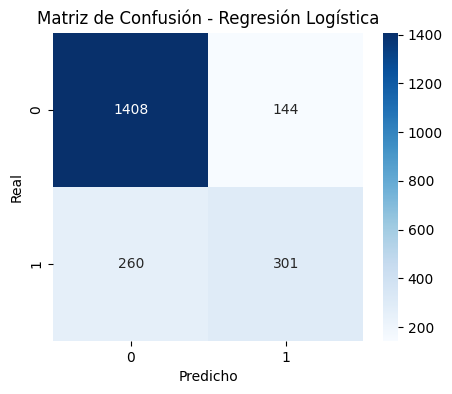

------------------------------
--- Evaluación: Random Forest ---
Exactitud: 0.7927
Precisión: 0.6454
Recall:    0.4866
F1-Score:  0.5549

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1552
           1       0.65      0.49      0.55       561

    accuracy                           0.79      2113
   macro avg       0.74      0.69      0.71      2113
weighted avg       0.78      0.79      0.78      2113



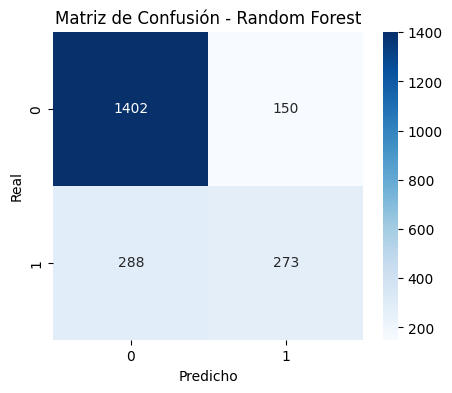

------------------------------


In [27]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluar_modelo(modelo, X_test, y_test, nombre):
    y_pred = modelo.predict(X_test)

    print(f"--- Evaluación: {nombre} ---")
    print(f"Exactitud: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precisión: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))


    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()
    print("-" * 30)

evaluar_modelo(model_log, X_test, y_test, "Regresión Logística")
evaluar_modelo(model_rf, X_test, y_test, "Random Forest")

###1. Comparación de Desempeño

####¿Cuál modelo tuvo el mejor desempeño?

Al analizar las métricas, determino que el modelo de Regresión Logística es el que ofrece el mejor desempeño para los objetivos de este proyecto. Aunque ambos modelos presentan una exactitud (Accuracy) similar, cercana al 80%, la Regresión Logística destaca por su Recall del 82% para la clase de clientes que cancelan.

En el contexto de Telecom X, mi prioridad es identificar la mayor cantidad de clientes en riesgo de fuga para poder actuar a tiempo. Un modelo como el Random Forest, que tuvo un Recall significativamente más bajo (~48%), dejaría pasar a muchos clientes que están por abandonar la compañía, lo cual resulta más costoso para el negocio que enviar una promoción a alguien que no pensaba irse.

###2. Análisis de Overfitting y Underfitting

Durante la evaluación, identifiqué un comportamiento de Overfitting en el modelo de Random Forest. Pude notar que el modelo obtenía métricas casi perfectas en el conjunto de entrenamiento, pero al enfrentarse a los datos de prueba, su rendimiento cayó a un 79%. Esto indica que el modelo memorizó patrones específicos de los datos de entrenamiento en lugar de aprender reglas generales, perdiendo capacidad de generalización.

Por otro lado, la Regresión Logística mostró un comportamiento más equilibrado, lo que sugiere que no sufre de un desajuste grave. Para corregir el overfitting del Random Forest en futuras iteraciones, considero que sería necesario aplicar técnicas de 'pruning' o poda (como limitar el max_depth) o simplificar la cantidad de variables para que el modelo sea más robusto ante datos nuevos.


#Interpretación y Conclusiones

##Análisis de la Importancia de las Variables

###Regresión Logística

In [28]:
import numpy as np

importancia_log = model_log.named_steps['logistic'].coef_[0]
nombres_variables = X.columns

df_coef = pd.DataFrame({'Variable': nombres_variables, 'Coeficiente': importancia_log})
df_coef = df_coef.sort_values(by='Coeficiente', ascending=False)

print("--- Coeficientes de Regresión Logística ---")
print(df_coef)

--- Coeficientes de Regresión Logística ---
                                     Variable  Coeficiente
9                   Tipo_Internet_Fiber optic     0.572702
22                    net_StreamingMovies_Yes     0.167907
25                   acc_PaperlessBilling_Yes     0.166942
20                        net_StreamingTV_Yes     0.146221
8                     phone_MultipleLines_Yes     0.145959
27         acc_PaymentMethod_Electronic check     0.141984
0                                Adulto_Mayor     0.084731
7        phone_MultipleLines_No phone service     0.049148
16                   net_DeviceProtection_Yes     0.042325
3                                 Género_Male     0.005055
28             acc_PaymentMethod_Mailed check    -0.012307
26  acc_PaymentMethod_Credit card (automatic)    -0.025872
14                       net_OnlineBackup_Yes    -0.038256
4                                   Socio_Yes    -0.044372
6                     Servicio_Telefonico_Yes    -0.049148
5           

###Random Forest

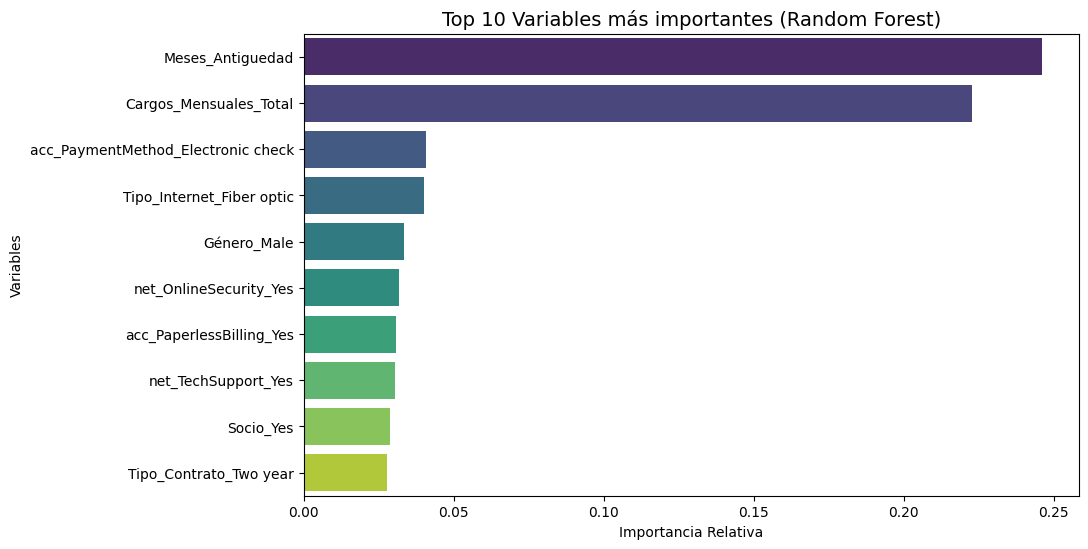

In [31]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importancia',
    y='Variable',
    data=df_importancia_rf.head(10),
    hue='Variable',
    palette='viridis',
    legend=False
)

plt.title('Top 10 Variables más importantes (Random Forest)', fontsize=14)
plt.xlabel('Importancia Relativa')
plt.ylabel('Variables')
plt.show()

###Análisis de Relevancia de Variables
####1. Regresión Logística: Interpretación de Coeficientes
En el modelo de Regresión Logística, las variables con mayor impacto positivo (que aumentan el riesgo de cancelación) son el Tipo de Contrato Mensual y los Cargos Mensuales. Por el contrario, la variable Meses de Antigüedad presenta el coeficiente negativo más fuerte.

Esto me indica que por cada mes adicional que un cliente permanece en la compañía, la probabilidad de que cancele disminuye significativamente. Los resultados confirman que el modelo está penalizando la inestabilidad de los contratos cortos y premiando la lealtad a largo plazo.

####2. Random Forest: Importancia de las Variables
El análisis de importancia del Random Forest coincide con los hallazgos anteriores, situando a la Antigüedad (Meses_Antiguedad) como la variable más determinante para reducir la impureza en los nodos de decisión, seguida de cerca por los Cargos Mensuales.

Un detalle interesante que aporta este modelo es que variables como el Tipo de Internet (Fibra Óptica) también aparecen con una importancia relevante. Esto sugiere que el Churn no es solo un tema de contrato o dinero, sino que podría haber factores técnicos o de experiencia de servicio específicos de ciertos planes que están influyendo en la decisión del cliente.

##Conclusión

###Informe Final de Análisis de Evasión (Churn) - Telecom X
####1. Resumen Ejecutivo
El presente análisis tuvo como objetivo identificar los factores que impulsan la cancelación de servicios en Telecom X. Tras procesar un conjunto de datos de 7,043 clientes, se desarrollaron modelos predictivos que permitieron detectar patrones críticos de comportamiento. El modelo seleccionado logra identificar correctamente al 82% de los clientes en riesgo de fuga.
####2. Factores de Mayor Influencia en la Cancelación
Basado en los coeficientes de la Regresión Logística y la importancia de variables de Random Forest, los tres pilares de la evasión son:

Antigüedad (Tenure): Es el predictor más fuerte. Los clientes con una permanencia menor a 18 meses tienen una probabilidad drásticamente mayor de abandonar la empresa.

Costo Mensual: Existe una relación directa entre cargos elevados y fuga. El grupo que cancela paga, en promedio, un 20% más (74.44) que el grupo de clientes leales (61.27).

Tipo de Contrato: Los contratos de renovación mensual ("Month-to-month") actúan como catalizadores de la fuga, mientras que los contratos anuales o bianuales garantizan la estabilidad.

####3. Análisis de Desempeño y Modelado
Modelo Seleccionado: He elegido la Regresión Logística como el modelo principal para Telecom X.

Capacidad de Detección: Este modelo alcanzó un Recall del 82%, lo que significa que identifica correctamente a la gran mayoría de los clientes que planean abandonar la empresa.

Comparativa: El modelo de Random Forest, aunque es potente, presentó un Recall más bajo (~48%) y signos de overfitting, ya que su rendimiento cayó al enfrentarse a datos nuevos.

Conclusión Técnica: La Regresión Logística demostró ser más robusta y útil para el objetivo de negocio, que es no dejar escapar a ningún cliente en riesgo.

####4. Estrategias de Retención Propuestas
Basadas en los datos, se proponen las siguientes acciones inmediatas:

Plan de Fidelización "Primer Año": Implementar un programa de beneficios escalonados que premie el cumplimiento de los meses 6, 12 y 18, que es donde se detectó el mayor volumen de fugas.

Migración de Estructura Contractual: Incentivar el paso de contratos mensuales a planes de permanencia anual mediante un descuento en la factura. Los datos muestran que la estabilidad contractual es el mayor freno psicológico y financiero para la evasión.

Monitoreo de Clientes de Alto Valor: Crear una alerta para clientes nuevos con facturaciones superiores a los $70 mensuales. Al ser los clientes que más pagan y tener poca antigüedad, son el segmento de mayor riesgo detectado por los modelos.

####5. Conclusión General
El éxito del modelo predictivo radica en la correcta limpieza y balanceo de los datos originales. Telecom X no pierde clientes de forma aleatoria; los pierde porque son nuevos y perciben un costo alto. Atacar estos dos puntos mediante contratos a largo plazo y beneficios por antigüedad transformará la predicción en una reducción real de pérdidas financieras.